In [2]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """ 0.650500 0.720500 0.796500 0.842500 0.890500 0.930000 0.941000
0.641000 0.732500 0.806000 0.869000 0.903500 0.919500 0.949000
0.643000 0.723500 0.801000 0.854500 0.902500 0.930000 0.949500
0.637000 0.739500 0.796000 0.846000 0.895500 0.937000 0.943000
0.623500 0.734000 0.814000 0.884000 0.923500 0.948500 0.966000
0.655000 0.745500 0.806500 0.869000 0.924000 0.939500 0.960000
0.637500 0.735500 0.804500 0.877000 0.916500 0.945000 0.968000
0.615000 0.736500 0.838000 0.887500 0.933500 0.952500 0.970000
0.641500 0.745000 0.839500 0.901000 0.936500 0.956000 0.973500
0.642000 0.746500 0.847000 0.904500 0.937000 0.965500 0.978000
0.638000 0.739000 0.844000 0.888000 0.943500 0.953500 0.973000
0.635000 0.746500 0.828500 0.913000 0.947500 0.960500 0.976000
0.624000 0.757500 0.859000 0.921500 0.945000 0.974000 0.983000
0.635000 0.768500 0.855500 0.904000 0.948000 0.970500 0.984000
0.624500 0.759000 0.860500 0.912500 0.954000 0.972000 0.981000
0.650000 0.761500 0.845500 0.908500 0.950000 0.973000 0.981500 """


run1 = np.loadtxt(StringIO(data_str1))
# run2 = np.loadtxt(StringIO(data_str2))
# run3 = np.loadtxt(StringIO(data_str3))
# run4 = np.loadtxt(StringIO(data_str4))
# run5 = np.loadtxt(StringIO(data_str5))
# run6 = np.loadtxt(StringIO(data_str6))
# run7 = np.loadtxt(StringIO(data_str7))
# run8 = np.loadtxt(StringIO(data_str8))
# run9 = np.loadtxt(StringIO(data_str9))
# run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1])

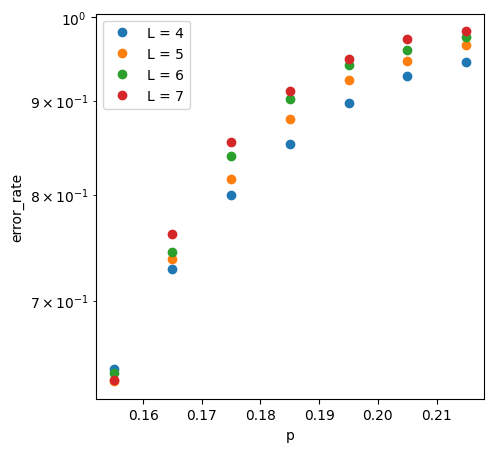

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.155, 0.165, 0.175, 0.185, 0.195, 0.205, 0.215]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [4]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.155, 0.165, 0.175, 0.185, 0.195, 0.205, 0.215]), 4)
L = np.repeat(np.array([4,5,6,7]), 7)
rate = error_rate.flatten()
n = 8000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [6]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.15579684  1.44832587  0.65739111  3.06514439 -7.33083606]
Parameter standard deviations: [0.00140759 0.07976789 0.01399472 0.25457311 0.95902915]


np.float64(53.07843786307401)

In [37]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.16043437  1.14909582  0.63189556  2.99073111 -8.54394372  7.10476885]
Parameter standard deviations: [8.33809859e-04 6.80022513e-02 1.10357722e-02 3.15195570e-01
 1.86191592e+00 3.81714903e+00]


np.float64(14.9648330916895)

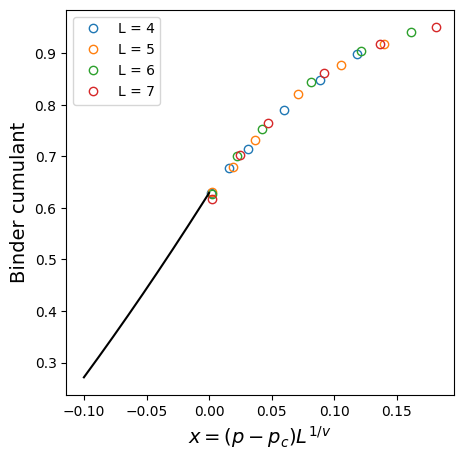

In [38]:
pc = 0.15943198
nu = 1.29968732
A = 0.62915787
B = 3.84693126
C = 2.68549348
# D = -149.66927112
p = [0.16, 0.165, 0.17, 0.18, 0.19, 0.2]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.1, 0, 1000)
y_data = A + B*x_data + C*(x_data**2) #+D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()